# Delirium Prediction Model - MIMIC

## Overview
- **Models**: Logistic Regression, Random Forest, XGBoost, Bidirectional LSTM
- **Evaluation**: 5-Fold Stratified Cross-Validation
- **Metrics**: ROC-AUC, AU-PRC, PPV, NPV, MCC, Specificity@90% Sensitivity

## 1. Imports

In [157]:
import numpy as np
import pandas as pd
import os
import sys
import random
import warnings
warnings.filterwarnings('ignore')

# Scipy & Stats
import scipy
import statsmodels.stats.api as sms

# Sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, recall_score, matthews_corrcoef
)

# XGBoost
from xgboost import XGBClassifier

# Visualization
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Lambda, Dropout, Dense, 
    Masking, Input, Reshape, Embedding, Concatenate
)
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.20.0
Pandas version: 3.0.0


## 2. Configuration & Seed

In [158]:
# Random Seed for Reproducibility
SEED_VALUE = 36
np.random.seed(SEED_VALUE)
random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

# GPU Configuration
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU available: {len(gpus)} device(s)")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU available, using CPU")

No GPU available, using CPU


In [250]:
# =============================================================================
# EXPERIMENT PARAMETERS - MODIFY HERE
# =============================================================================
MIN_TIME = 2       # Observation window (hours): 12, 24, 48
SKIP_TIME = 0      # Prediction horizon (hours): 12, 24, 48, 72, 96
HIGH_RECALL = False # True for higher recall model

# Model Hyperparameters
BATCH_SIZE = 128
PARAMS = {
    'lr': 0.000075,
    'hidden_units': 128,
    'dropout': 0.2,
    'epochs': 50
}

# Task identifier
TASK = f'{MIN_TIME}_{SKIP_TIME}'
print(f"Task: {TASK} (min_time={MIN_TIME}h, skip_time={SKIP_TIME}h, high_recall={HIGH_RECALL})")

Task: 2_0 (min_time=2h, skip_time=0h, high_recall=False)


## 3. Data Loading

In [251]:
# Data paths
DATA_DIR = "../Data/preprocessed"
POS_PATH = f"{DATA_DIR}/pos_mimic_imputed_24los.csv"
NEG_PATH = f"{DATA_DIR}/neg_mimic_imputed_24los.csv"

# Load positive and negative data separately
mimic_pos = pd.read_csv(POS_PATH)
mimic_neg = pd.read_csv(NEG_PATH)

print(f"Positive data shape: {mimic_pos.shape}")
print(f"Negative data shape: {mimic_neg.shape}")

# Combine into single dataframe
mimic_df = pd.concat([mimic_pos, mimic_neg], axis=0, ignore_index=True)

print(f"\nCombined data shape: {mimic_df.shape}")
print(f"Columns: {mimic_df.columns.tolist()}")

Positive data shape: (231475, 27)
Negative data shape: (363576, 27)

Combined data shape: (595051, 27)
Columns: ['patientunitstayid', 'itemoffset', 'Gender', 'Age', 'Height', 'Weight', 'Heart Rate', 'O2 Saturation', 'Glucose', 'Temperature', 'Sodium', 'BUN', 'WBC', 'Hemoglobin', 'Platelets', 'Potassium', 'Chloride', 'Bicarbonate', 'Creatinine', 'Sofa', 'Sofa_wo_gcs', 'Ventilation', 'CAM', 'Vasopressor dose', 'LOS', 'labelrec', 'labelpt']


In [252]:
# Check data sample
print("Sample data:")
mimic_df.head()

Sample data:


,patientunitstayid,itemoffset,Gender,Age,Height,Weight,Heart Rate,O2 Saturation,Glucose,Temperature,...,Bicarbonate,Creatinine,Sofa,Sofa_wo_gcs,Ventilation,CAM,Vasopressor dose,LOS,labelrec,labelpt
0,200034,1,1,54,169.350688,45.0,102.0,100.0,114.0,33.888889,...,24.0,0.5,0.0,0.0,0.0,1.0,0.0,77.208,0.0,1.0
1,200034,2,1,54,169.350688,45.0,102.0,100.0,105.0,33.888889,...,24.0,0.5,0.0,0.0,0.0,1.0,0.0,77.208,0.0,1.0
2,200034,4,1,54,169.350688,45.0,102.0,100.0,94.0,33.888889,...,24.0,0.5,0.0,0.0,1.0,1.0,0.0,77.208,0.0,1.0
3,200034,5,1,54,169.350688,45.0,103.0,100.0,106.0,34.444444,...,24.0,0.5,0.0,0.0,0.0,1.0,0.0,77.208,0.0,1.0
4,200034,6,1,54,169.350688,45.0,78.0,100.0,106.0,35.666667,...,24.0,0.5,0.0,0.0,0.0,1.0,0.0,77.208,0.0,1.0


## 4. Data Exploration

In [253]:
# Check data structure (already preprocessed with Vasopressor dose)
print("Data columns and types:")
print(mimic_df.dtypes)
print(f"\nVasopressor dose stats:\n{mimic_df['Vasopressor dose'].describe()}")

Data columns and types:
patientunitstayid      int64
itemoffset             int64
Gender                 int64
Age                    int64
Height               float64
Weight               float64
Heart Rate           float64
O2 Saturation        float64
Glucose              float64
Temperature          float64
Sodium               float64
BUN                  float64
WBC                  float64
Hemoglobin           float64
Platelets            float64
Potassium            float64
Chloride             float64
Bicarbonate          float64
Creatinine           float64
Sofa                 float64
Sofa_wo_gcs          float64
Ventilation          float64
CAM                  float64
Vasopressor dose     float64
LOS                  float64
labelrec             float64
labelpt              float64
dtype: object

Vasopressor dose stats:
count    595051.000000
mean          0.024916
std           0.474144
min           0.000000
25%           0.000000
50%           0.000000
75%           0.

In [254]:
# Data is already split - check label distribution
print(f"Label distribution (labelpt):")
print(mimic_df['labelpt'].value_counts())
print(f"\nPositive (Delirium) patients: {mimic_pos['patientunitstayid'].nunique()}")
print(f"Negative (No Delirium) patients: {mimic_neg['patientunitstayid'].nunique()}")
print(f"Total unique patients: {mimic_df['patientunitstayid'].nunique()}")

Label distribution (labelpt):
labelpt
0.0    363576
1.0    231475
Name: count, dtype: int64

Positive (Delirium) patients: 1262
Negative (No Delirium) patients: 4958
Total unique patients: 6220


## 5. Time Window Selection Functions

In [255]:
def pos_selection(df_pos, skip_time, min_time):
    """
    Select time windows for delirium-positive patients.
    
    For positive patients, we select data from:
    (t - skip_time - min_time) to (t - skip_time)
    where t is the first delirium onset time.
    
    Args:
        df_pos: DataFrame with positive patients
        skip_time: Prediction horizon (hours before delirium)
        min_time: Observation window length (hours)
    
    Returns:
        DataFrame with selected time windows
    """
    posl = []
    all_matches = df_pos[df_pos['labelpt'] == df_pos['labelrec']]
    
    for p_id in all_matches['patientunitstayid'].unique():
        df_p_id = df_pos[df_pos['patientunitstayid'] == p_id]
        idx = all_matches[all_matches['patientunitstayid'] == p_id].index[0]
        t = df_pos.loc[idx, 'itemoffset']  # First delirium time
        
        if t > (min_time + skip_time):
            window = df_p_id[
                (df_p_id['itemoffset'] < (t - skip_time)) & 
                (df_p_id['itemoffset'] > (t - skip_time - min_time))
            ]
            posl.append(window)
    
    return pd.concat(posl, axis=0) if posl else pd.DataFrame(columns=df_pos.columns)


def neg_selection(df_neg, skip_time, min_time):
    """
    Select time windows for delirium-negative patients.
    
    For negative patients, we select data from:
    (t - skip_time - min_time) to (t - skip_time)
    where t is the last record time.
    
    Args:
        df_neg: DataFrame with negative patients
        skip_time: Prediction horizon (hours)
        min_time: Observation window length (hours)
    
    Returns:
        DataFrame with selected time windows
    """
    negl = []
    
    for p_id in df_neg['patientunitstayid'].unique():
        df_p_id = df_neg[df_neg['patientunitstayid'] == p_id]
        t = df_p_id['itemoffset'].iloc[-1]  # Last record time
        
        if t > (min_time + skip_time):
            window = df_p_id[
                (df_p_id['itemoffset'] < (t - skip_time)) & 
                (df_p_id['itemoffset'] > (t - skip_time - min_time))
            ]
            negl.append(window)
    
    return pd.concat(negl, axis=0) if negl else pd.DataFrame(columns=df_neg.columns)

In [256]:
# Apply time window selection
# mimic_pos and mimic_neg are already loaded from separate files in cell-7
mimic_pos_filtered = pos_selection(mimic_pos, SKIP_TIME, MIN_TIME)
mimic_neg_filtered = neg_selection(mimic_neg, SKIP_TIME, MIN_TIME)

print(f"Positive patients after filtering: {mimic_pos_filtered['patientunitstayid'].nunique()}")
print(f"Negative patients after filtering: {mimic_neg_filtered['patientunitstayid'].nunique()}")

# Combine
mimic_df_filtered = pd.concat([mimic_pos_filtered, mimic_neg_filtered], axis=0)
print(f"\nTotal filtered data shape: {mimic_df_filtered.shape}")
print(f"Total filtered patients: {mimic_df_filtered['patientunitstayid'].nunique()}")

Positive patients after filtering: 1148
Negative patients after filtering: 4756

Total filtered data shape: (5904, 27)
Total filtered patients: 5904


## 6. Data Transformation for Model Input

In [257]:
# Column order for model input (matching preprocessed data structure)
COLUMNS_ORD = [
    'patientunitstayid', 'itemoffset', 
    # Categorical (3)
    'Gender', 'Sofa', 'Sofa_wo_gcs',
    # Numerical (18)
    'Age', 'Height', 'Weight', 
    'Heart Rate', 'O2 Saturation', 'Glucose', 'Temperature', 
    'Sodium', 'BUN', 'WBC', 'Hemoglobin', 'Platelets', 
    'Potassium', 'Chloride', 'Bicarbonate', 'Creatinine',
    'Ventilation', 'Vasopressor dose',
    # Label (use labelpt for patient-level label)
    'labelpt'
]

print(f"Feature columns: {len(COLUMNS_ORD) - 4} features")
print(f"  - Categorical: 3 (Gender, Sofa, Sofa_wo_gcs)")
print(f"  - Numerical: 18")
print(f"\nVerify columns exist:")
missing = [c for c in COLUMNS_ORD if c not in mimic_df.columns]
if missing:
    print(f"  WARNING - Missing columns: {missing}")
else:
    print("  All columns found!")

Feature columns: 20 features
  - Categorical: 3 (Gender, Sofa, Sofa_wo_gcs)
  - Numerical: 18

Verify columns exist:
  All columns found!


In [258]:
def reader_deli(df_list, columns_ord, verbose=True):
    """
    Transform patient DataFrames into model input format.
    
    Args:
        df_list: List of DataFrames, one per patient
        columns_ord: Column order for features
        verbose: Print progress
    
    Returns:
        PID: Patient IDs
        X_cat: Categorical features (N, T, 3)
        X_noncat: Numerical features (N, T, 18)
        ts: Timestamps
        nrows: Number of rows per patient
        y: Labels
    """
    X_noncat, X_cat, deli, nrows, ts, PID = [], [], [], [], [], []
    nb_unit_stays = len(df_list)
    
    for i, df in enumerate(df_list):
        if verbose:
            sys.stdout.write(f'\rProcessing patient {i+1} of {nb_unit_stays}...')
        
        # Reorder columns
        dft = df[columns_ord].copy()
        narr = np.array(dft)
        
        pid = narr[0, 0]              # Patient ID
        x_cat = narr[:, 2:5]          # Categorical: columns 2-4
        x_noncat = narr[:, 5:-1]      # Numerical: columns 5 to second-last
        labeldeli = narr[0, -1]       # Label: last column
        time = narr[:, 1]             # Time: column 1
        
        X_cat.append(x_cat)
        X_noncat.append(x_noncat)
        deli.append(labeldeli)
        ts.append(time)
        nrows.append(narr.shape[0])
        PID.append(pid)
    
    if verbose:
        print(" Done!")
    
    return (
        np.array(PID), 
        np.array(X_cat, dtype=object), 
        np.array(X_noncat, dtype=object), 
        np.array(ts, dtype=object), 
        np.array(nrows), 
        np.array(deli)
    )

In [259]:
# Group by patient
patient_groups = mimic_df_filtered.groupby('patientunitstayid')
patient_dfs = [frame for _, frame in patient_groups]

print(f"Number of patients: {len(patient_dfs)}")

Number of patients: 5904


In [260]:
# Transform to model input
PID, X_cat, X_num, timestamps, nrows, y = reader_deli(patient_dfs, COLUMNS_ORD)

print(f"\nData shapes:")
print(f"  PID: {PID.shape}")
print(f"  X_cat: {len(X_cat)} patients")
print(f"  X_num: {len(X_num)} patients")
print(f"  y: {y.shape}")
print(f"\nLabel distribution: {np.unique(y, return_counts=True)}")

Processing patient 5904 of 5904... Done!

Data shapes:
  PID: (5904,)
  X_cat: 5904 patients
  X_num: 5904 patients
  y: (5904,)

Label distribution: (array([0., 1.]), array([4756, 1148]))


## 7. Padding for Fixed-Length Input

In [261]:
def pad_sequence(arr, max_len):
    """
    Pad sequence to fixed length with zeros.
    
    Args:
        arr: Input array (T, F)
        max_len: Target length
    
    Returns:
        Padded array (max_len, F)
    """
    tmp = np.zeros((max_len, arr.shape[1]))
    tmp[:arr.shape[0], :arr.shape[1]] = arr
    return tmp


def pad_all_sequences(X, max_len):
    """
    Pad all sequences to fixed length.
    
    Args:
        X: List/array of variable-length sequences
        max_len: Target length
    
    Returns:
        Numpy array (N, max_len, F)
    """
    return np.array([pad_sequence(x, max_len) for x in X])

In [263]:
# Pad sequences to MIN_TIME length
X_cat_padded = pad_all_sequences(X_cat, MIN_TIME)
X_num_padded = pad_all_sequences(X_num, MIN_TIME)

# Concatenate numerical and categorical features
X_combined = np.concatenate([X_num_padded, X_cat_padded], axis=-1)

print(f"Padded shapes:")
print(f"  X_num_padded: {X_num_padded.shape}")
print(f"  X_cat_padded: {X_cat_padded.shape}")
print(f"  X_combined: {X_combined.shape}")
print(f"  y: {y.shape}")

Padded shapes:
  X_num_padded: (5904, 2, 18)
  X_cat_padded: (5904, 2, 3)
  X_combined: (5904, 2, 21)
  y: (5904,)


## 8. Class Weighting

In [264]:
def get_class_weights(data, label, high_recall=False):
    """
    Compute class weights for imbalanced data.
    
    Args:
        data: Feature data
        label: Labels
        high_recall: If True, use higher weight for positive class
    
    Returns:
        Dictionary with class weights
    """
    neg = np.sum(label == 0)
    pos = len(label) - neg
    total = pos + neg
    
    weight_for_0 = (1 / neg) * (total / 2.0)
    weight_for_1 = (1 / pos) * total
    
    if high_recall:
        return {0: weight_for_0, 1: weight_for_1}
    else:
        return {0: weight_for_0, 1: weight_for_1 / 2}

In [265]:
# Check class weights
cw = get_class_weights(X_combined, y, HIGH_RECALL)
print(f"Class weights: {cw}")
print(f"Class 0 (No Delirium): {np.sum(y == 0)}")
print(f"Class 1 (Delirium): {np.sum(y == 1)}")

Class weights: {0: np.float64(0.6206896551724138), 1: np.float64(2.5714285714285716)}
Class 0 (No Delirium): 4756
Class 1 (Delirium): 1148


## 9. Model Definitions

In [266]:
def build_lstm_model(input_shape, params):
    """
    Build Bidirectional LSTM model.
    
    Architecture:
        - Input1: Numerical features (T, 18)
        - Input2: Categorical features (T, 3) -> Embedding -> (T, 6)
        - Concatenate -> Masking -> BiLSTM -> Dropout -> Dense(1, sigmoid)
    
    Args:
        input_shape: Tuple (timesteps, features)
        params: Dictionary with lr, hidden_units, dropout
    
    Returns:
        Compiled Keras model
    """
    timesteps = input_shape[0]
    
    # Numerical input
    input_num = Input(shape=(timesteps, 18), name='input_numerical')
    
    # Categorical input with embedding
    input_cat = Input(shape=(timesteps, 3), name='input_categorical')
    x_cat = Embedding(50, 2, name='embedding', mask_zero=True)(input_cat)
    x_cat = Reshape((timesteps, 6), name='reshape_embedding')(x_cat)
    
    # Concatenate
    merged = Concatenate(axis=-1, name='concat')([input_num, x_cat])
    masked = Masking(mask_value=0., name='masking')(merged)
    
    # BiLSTM
    lstm_out = Bidirectional(
        LSTM(units=params['hidden_units'], 
             kernel_initializer='glorot_normal',
             return_sequences=False),
        name='bilstm'
    )(masked)
    lstm_out = Dropout(params['dropout'])(lstm_out)
    
    # Output
    output = Dense(1, activation='sigmoid', name='output')(lstm_out)
    
    # Compile
    model = Model(inputs=[input_num, input_cat], outputs=output)
    optimizer = optimizers.Adam(learning_rate=params['lr'], decay=1e-6)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    return model

In [267]:
# # Test model build
# test_model = build_lstm_model((MIN_TIME, 21), PARAMS)
# test_model.summary()

## 10. Training Functions

In [268]:
def train_lstm(X_train, y_train, X_test, params, savepath, high_recall=False):
    """
    Train LSTM model.
    
    Args:
        X_train: Training features (N, T, F)
        y_train: Training labels
        X_test: Test features
        params: Hyperparameters
        savepath: Path to save model
        high_recall: Use high recall class weights
    
    Returns:
        Predicted probabilities on X_test
    """
    cw = get_class_weights(X_train, y_train, high_recall)
    model = build_lstm_model((X_train.shape[1], X_train.shape[2]), params)
    
    # Split features
    X_train_num = X_train[:, :, :18]
    X_train_cat = X_train[:, :, 18:]
    X_test_num = X_test[:, :, :18]
    X_test_cat = X_test[:, :, 18:]
    
    # Train
    history = model.fit(
        [X_train_num, X_train_cat], y_train,
        batch_size=BATCH_SIZE,
        class_weight=cw,
        epochs=params['epochs'],
        verbose=1,
        shuffle=True
    )
    
    # Save and predict
    model.save(savepath)
    probs = model.predict([X_test_num, X_test_cat])
    
    return probs.flatten(), history


def train_sklearn(X_train, y_train, X_test, model_type, high_recall=False):
    """
    Train sklearn model (LR, RF, or XGB).
    
    Args:
        X_train: Training features
        y_train: Training labels
        X_test: Test features
        model_type: 'LR', 'RF', or 'XGB'
        high_recall: Use high recall class weights
    
    Returns:
        Predicted probabilities
    """
    cw = get_class_weights(X_train, y_train, high_recall)
    
    # Flatten for sklearn
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)
    
    if model_type == 'LR':
        clf = LogisticRegression(
            random_state=SEED_VALUE, 
            solver='liblinear',
            class_weight=cw
        )
    elif model_type == 'RF':
        clf = RandomForestClassifier(
            n_estimators=300, 
            max_depth=6,
            random_state=SEED_VALUE, 
            max_features=8,
            class_weight=cw
        )
    elif model_type == 'XGB':
        # XGBoost uses scale_pos_weight instead of class_weight
        # scale_pos_weight = weight_for_1 / weight_for_0
        scale_pos_weight = cw[1] / cw[0]
        clf = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            random_state=SEED_VALUE,
            scale_pos_weight=scale_pos_weight,
            use_label_encoder=False,
            eval_metric='logloss'
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    
    clf.fit(X_train_flat, y_train)
    probs = clf.predict_proba(X_test_flat)[:, 1]
    
    return probs

## 11. Evaluation Metrics

In [269]:
def compute_metrics(y_true, y_probs):
    """
    Compute evaluation metrics.
    
    Args:
        y_true: True labels
        y_probs: Predicted probabilities
    
    Returns:
        Dictionary with all metrics
    """
    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Specificity at 90% sensitivity
    specat90 = 1 - fpr[tpr >= 0.90][0] if any(tpr >= 0.90) else 0
    
    # Interpolated TPR for averaging
    intrp = np.interp(np.linspace(0, 1, 100), fpr, tpr)
    intrp[0] = 0.0
    
    # Confusion matrix metrics
    y_pred = (y_probs >= 0.5).astype(int)
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0
    NPV = TN / (TN + FN) if (TN + FN) > 0 else 0
    mcc = matthews_corrcoef(y_true, y_pred)
    recall_single = recall_score(y_true, y_pred)
    
    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    auc_prc = auc(recall, precision)
    prs = np.interp(np.linspace(0, 1, 100), recall[::-1], precision[::-1])
    prs[0] = 1.0
    prs[-1] = 0.0
    
    return {
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'intrp': intrp,
        'specat90': specat90,
        'ppv': PPV,
        'npv': NPV,
        'mcc': mcc,
        'rec_single': recall_single,
        'auc_prc': auc_prc,
        'prc': precision,
        'rec': recall,
        'prs': prs
    }

In [270]:
def aggregate_cv_metrics(cv_results):
    """
    Aggregate cross-validation results with confidence intervals.
    
    Args:
        cv_results: Dictionary of fold results
    
    Returns:
        Dictionary with aggregated metrics
    """
    mean_fpr = np.linspace(0, 1, 100)
    mean_recall = np.linspace(0, 1, 100)
    
    # ROC
    mean_tpr = np.mean([cv_results[k]['intrp'] for k in cv_results], axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = np.std([cv_results[k]['intrp'] for k in cv_results], axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std([cv_results[k]['auc'] for k in cv_results])
    
    # PR curve
    mean_precision = np.mean([cv_results[k]['prs'] for k in cv_results], axis=0)
    mean_precision[0] = 1.0
    mean_precision[-1] = 0.0
    mean_auc_prc = auc(mean_recall, mean_precision)
    std_auc_prc = np.std([cv_results[k]['auc_prc'] for k in cv_results])
    
    # Other metrics
    ppvs = np.mean([cv_results[k]['ppv'] for k in cv_results])
    npvs = np.mean([cv_results[k]['npv'] for k in cv_results])
    mccs = np.mean([cv_results[k]['mcc'] for k in cv_results])
    specat90 = np.mean([cv_results[k]['specat90'] for k in cv_results])
    recall_single = np.mean([cv_results[k]['rec_single'] for k in cv_results])
    
    # 95% Confidence Intervals
    l_CI, h_CI = sms.DescrStatsW([cv_results[k]['auc'] for k in cv_results]).tconfint_mean()
    auprc_l_CI, auprc_h_CI = sms.DescrStatsW([cv_results[k]['auc_prc'] for k in cv_results]).tconfint_mean()
    p_l_CI, p_h_CI = sms.DescrStatsW([cv_results[k]['ppv'] for k in cv_results]).tconfint_mean()
    r_l_CI, r_h_CI = sms.DescrStatsW([cv_results[k]['rec_single'] for k in cv_results]).tconfint_mean()
    
    # Print results
    print(f"Mean AUC: {mean_auc:.4f} +/- {std_auc:.4f} (95% CI: {l_CI:.4f}-{h_CI:.4f})")
    print(f"Mean AUPRC: {mean_auc_prc:.4f} +/- {std_auc_prc:.4f} (95% CI: {auprc_l_CI:.4f}-{auprc_h_CI:.4f})")
    print(f"PPV: {ppvs:.4f} (95% CI: {p_l_CI:.4f}-{p_h_CI:.4f})")
    print(f"NPV: {npvs:.4f}")
    print(f"MCC: {mccs:.4f}")
    print(f"Spec@90: {specat90:.4f}")
    print(f"Recall: {recall_single:.4f} (95% CI: {r_l_CI:.4f}-{r_h_CI:.4f})")
    
    return {
        'mean_auc': mean_auc, 'std_auc': std_auc,
        'tpr': mean_tpr, 'std_tpr': std_tpr,
        'mean_auc_prc': mean_auc_prc, 'std_auc_prc': std_auc_prc,
        'mean_prc': mean_precision, 'mean_recall': mean_recall,
        'ppv': ppvs, 'npv': npvs, 'mcc': mccs,
        'spec@90': specat90, 'rec_single': recall_single,
        'l_CI': l_CI, 'h_CI': h_CI,
        'auprc_l_CI': auprc_l_CI, 'auprc_h_CI': auprc_h_CI,
        'p_l_CI': p_l_CI, 'p_h_CI': p_h_CI,
        'r_l_CI': r_l_CI, 'r_h_CI': r_h_CI
    }

## 12. Visualization

In [271]:
def plot_roc_curve(results, savepath=None):
    """
    Plot ROC curves for all models.
    """
    plt.figure(figsize=(8, 8))
    colors = ['b', 'r', 'orange', 'g']  # LR, RF, XGB, LSTM
    mean_fpr = np.linspace(0, 1, 100)
    
    for (model_name, result), color in zip(results.items(), colors):
        plt.plot(mean_fpr, result['tpr'],
                 label=f"{model_name}: AUC={result['mean_auc']:.4f}",
                 color=color, lw=2)
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random: 0.5000')
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('ROC Curves', fontsize=16)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(alpha=0.3)
    
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


def plot_pr_curve(results, baseline_ratio, savepath=None):
    """
    Plot Precision-Recall curves for all models.
    """
    plt.figure(figsize=(8, 8))
    colors = ['b', 'r', 'orange', 'g']  # LR, RF, XGB, LSTM
    mean_recall = np.linspace(0, 1, 100)
    
    for (model_name, result), color in zip(results.items(), colors):
        plt.plot(mean_recall, result['mean_prc'],
                 label=f"{model_name}: AUPRC={result['mean_auc_prc']:.4f}",
                 color=color, lw=2)
    
    plt.axhline(y=baseline_ratio, color='k', linestyle='--', lw=2, 
                label=f'Random: {baseline_ratio:.4f}')
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('Recall', fontsize=14)
    plt.ylabel('Precision', fontsize=14)
    plt.title('Precision-Recall Curves', fontsize=16)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(alpha=0.3)
    
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

## 13. Cross-Validation Pipeline

In [273]:
def run_cross_validation(X, y, model_type, n_splits=5):
    """
    Run stratified k-fold cross-validation.
    
    Args:
        X: Features
        y: Labels
        model_type: 'LR', 'RF', 'XGB', or 'LSTM'
        n_splits: Number of folds
    
    Returns:
        Aggregated metrics dictionary
    """
    cv_scores = {}
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED_VALUE)
    
    for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n--- Fold {fold}/{n_splits} ---")
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        print(f"Train: {len(y_train)} (pos: {sum(y_train)})")
        print(f"Test: {len(y_test)} (pos: {sum(y_test)})")
        
        # Train and predict
        if model_type == 'LSTM':
            suffix = '_recall' if HIGH_RECALL else ''
            savepath = f"mimic_{TASK}_{fold}_cv{suffix}.h5"
            probs, _ = train_lstm(X_train, y_train, X_test, PARAMS, savepath, HIGH_RECALL)
        else:
            probs = train_sklearn(X_train, y_train, X_test, model_type, HIGH_RECALL)

        # Compute metrics
        cv_scores[fold] = compute_metrics(y_test, probs)
        print(f"Fold {fold} AUC: {cv_scores[fold]['auc']:.4f}")
    
    # Aggregate
    print(f"\n=== {model_type} Cross-Validation Results ===")
    aggregated = aggregate_cv_metrics(cv_scores)
    
    return aggregated

## 14. Run Experiments

In [274]:
# Store all results
all_results = {}

### 14.1 Logistic Regression

In [ ]:
print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)
all_results['LR'] = run_cross_validation(X_combined, y, 'LR')

### 14.2 Random Forest

In [188]:
print("="*50)
print("RANDOM FOREST")
print("="*50)
all_results['RF'] = run_cross_validation(X_combined, y, 'RF')

RANDOM FOREST

--- Fold 1/5 ---
Train: 4226 (pos: 556.0)
Test: 1057 (pos: 139.0)
Fold 1 AUC: 0.8392

--- Fold 2/5 ---
Train: 4226 (pos: 556.0)
Test: 1057 (pos: 139.0)
Fold 2 AUC: 0.8164

--- Fold 3/5 ---
Train: 4226 (pos: 556.0)
Test: 1057 (pos: 139.0)
Fold 3 AUC: 0.7925

--- Fold 4/5 ---
Train: 4227 (pos: 556.0)
Test: 1056 (pos: 139.0)
Fold 4 AUC: 0.8263

--- Fold 5/5 ---
Train: 4227 (pos: 556.0)
Test: 1056 (pos: 139.0)
Fold 5 AUC: 0.8041

=== RF Cross-Validation Results ===
Mean AUC: 0.8156 +/- 0.0164 (95% CI: 0.7930-0.8384)
Mean AUPRC: 0.4814 +/- 0.0543 (95% CI: 0.4070-0.5577)
PPV: 0.4396 (95% CI: 0.4009-0.4782)
NPV: 0.9263
MCC: 0.3949
Spec@90: 0.4516
Recall: 0.5281 (95% CI: 0.4631-0.5930)


### 14.3 XGBoost

In [275]:
print("="*50)
print("XGBOOST")
print("="*50)
all_results['XGB'] = run_cross_validation(X_combined, y, 'XGB')

XGBOOST

--- Fold 1/5 ---
Train: 4723 (pos: 919.0)
Test: 1181 (pos: 229.0)
Fold 1 AUC: 0.7914

--- Fold 2/5 ---
Train: 4723 (pos: 918.0)
Test: 1181 (pos: 230.0)
Fold 2 AUC: 0.8132

--- Fold 3/5 ---
Train: 4723 (pos: 918.0)
Test: 1181 (pos: 230.0)
Fold 3 AUC: 0.8377

--- Fold 4/5 ---
Train: 4723 (pos: 918.0)
Test: 1181 (pos: 230.0)
Fold 4 AUC: 0.7962

--- Fold 5/5 ---
Train: 4724 (pos: 919.0)
Test: 1180 (pos: 229.0)
Fold 5 AUC: 0.7686

=== XGB Cross-Validation Results ===
Mean AUC: 0.8012 +/- 0.0231 (95% CI: 0.7694-0.8334)
Mean AUPRC: 0.5779 +/- 0.0490 (95% CI: 0.5100-0.6459)
PPV: 0.5887 (95% CI: 0.5078-0.6697)
NPV: 0.8805
MCC: 0.4342
Spec@90: 0.3934
Recall: 0.4843 (95% CI: 0.4370-0.5315)


### 14.4 Bidirectional LSTM

In [223]:
print("="*50)
print("BIDIRECTIONAL LSTM")
print("="*50)
all_results['LSTM'] = run_cross_validation(X_combined, y, 'LSTM')

BIDIRECTIONAL LSTM

--- Fold 1/5 ---
Train: 4751 (pos: 795.0)
Test: 1188 (pos: 198.0)
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4506 - loss: 0.7125
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5397 - loss: 0.6921
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5611 - loss: 0.6796
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5851 - loss: 0.6719
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5952 - loss: 0.6680
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6001 - loss: 0.6655
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6093 - loss: 0.6638
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6133 - loss: 0.6548
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6159 - loss: 0.6585
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6180 - loss: 0.6567
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy:

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Fold 1 AUC: 0.7048

--- Fold 2/5 ---
Train: 4751 (pos: 794.0)
Test: 1188 (pos: 199.0)
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5788 - loss: 0.6849
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6197 - loss: 0.6779
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6262 - loss: 0.6694
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6264 - loss: 0.6651
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6304 - loss: 0.6610
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6434 - loss: 0.6576
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6361 - loss: 0.6531
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6460 - loss: 0.6556
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6348 - loss: 0.6511
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6546 - loss: 0.6457
Epoch 11/50
38/38 ━━━━━━

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Fold 2 AUC: 0.6825

--- Fold 3/5 ---
Train: 4751 (pos: 794.0)
Test: 1188 (pos: 199.0)
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6098 - loss: 0.7088
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6011 - loss: 0.6867
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6047 - loss: 0.6810
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6140 - loss: 0.6750
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6251 - loss: 0.6687
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6268 - loss: 0.6675
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6434 - loss: 0.6575
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6348 - loss: 0.6634
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6268 - loss: 0.6602
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6415 - loss: 0.6551
Epoch 11/50
38/38 ━━━━━━

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Fold 3 AUC: 0.6875

--- Fold 4/5 ---
Train: 4751 (pos: 794.0)
Test: 1188 (pos: 199.0)
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5172 - loss: 0.7188
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5683 - loss: 0.6940
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5816 - loss: 0.6789
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6028 - loss: 0.6719
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6041 - loss: 0.6664
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6218 - loss: 0.6618
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6241 - loss: 0.6605
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6283 - loss: 0.6554
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6432 - loss: 0.6485
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6447 - loss: 0.6505
Epoch 11/50
38/38 ━━━━━

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Fold 4 AUC: 0.6655

--- Fold 5/5 ---
Train: 4752 (pos: 795.0)
Test: 1187 (pos: 198.0)
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5231 - loss: 0.7103
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5244 - loss: 0.6950
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5539 - loss: 0.6869
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5795 - loss: 0.6767
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5884 - loss: 0.6737
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5854 - loss: 0.6714
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6040 - loss: 0.6641
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6042 - loss: 0.6651
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6187 - loss: 0.6567
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6258 - loss: 0.6550
Epoch 11/50
38/38 ━━━━━

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Fold 5 AUC: 0.7058

=== LSTM Cross-Validation Results ===
Mean AUC: 0.6889 +/- 0.0150 (95% CI: 0.6684-0.7101)
Mean AUPRC: 0.2996 +/- 0.0203 (95% CI: 0.2730-0.3293)
PPV: 0.2777 (95% CI: 0.2483-0.3072)
NPV: 0.8924
MCC: 0.2171
Spec@90: 0.2622
Recall: 0.5851 (95% CI: 0.5614-0.6088)


## 15. Results Visualization

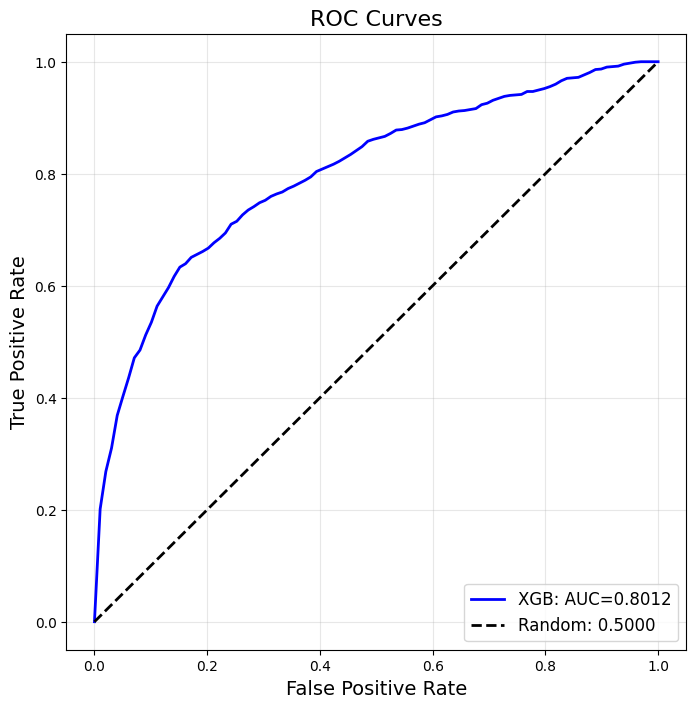

In [276]:
# Plot ROC curves
suffix = '_recall' if HIGH_RECALL else ''
plot_roc_curve(all_results, savepath=f'{TASK}_cv_mimic{suffix}_roc.png')

Baseline (positive ratio): 0.1944


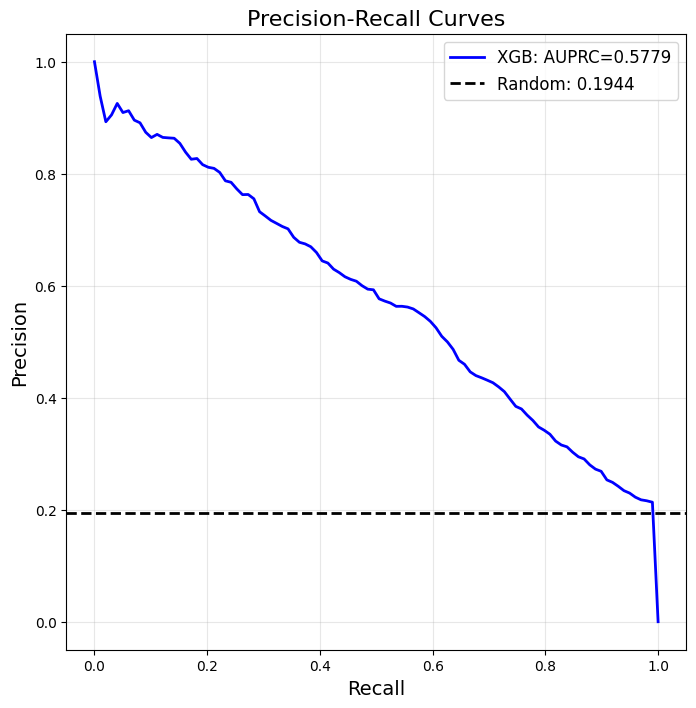

In [277]:
# Plot PR curves
baseline_ratio = sum(y) / len(y)
print(f"Baseline (positive ratio): {baseline_ratio:.4f}")
plot_pr_curve(all_results, baseline_ratio, savepath=f'{TASK}_cv_mimic{suffix}_pr.png')

## 16. Save Results

In [63]:
import json

# Save results to JSON
for model_name, result in all_results.items():
    suffix = '_recall' if HIGH_RECALL else ''
    filename = f'{MIN_TIME}min_{SKIP_TIME}skip_model_{model_name}_mimic{suffix}_CI.json'
    
    # Extract scalar metrics
    metrics_to_save = {
        'mean_auc': float(result['mean_auc']),
        'std_auc': float(result['std_auc']),
        'l_CI': float(result['l_CI']),
        'h_CI': float(result['h_CI']),
        'mean_auc_prc': float(result['mean_auc_prc']),
        'auprc_l_CI': float(result['auprc_l_CI']),
        'auprc_h_CI': float(result['auprc_h_CI']),
        'ppv': float(result['ppv']),
        'p_l_CI': float(result['p_l_CI']),
        'p_h_CI': float(result['p_h_CI']),
        'npv': float(result['npv']),
        'mcc': float(result['mcc']),
        'spec@90': float(result['spec@90']),
        'recall': float(result['rec_single']),
        'r_l_CI': float(result['r_l_CI']),
        'r_h_CI': float(result['r_h_CI']),
        'n_total': int(len(y)),
        'n_positive': int(sum(y)),
        'n_negative': int(len(y) - sum(y))
    }
    
    with open(filename, 'w') as f:
        json.dump(metrics_to_save, f, indent=2)
    
    print(f"Saved: {filename}")

Saved: 12min_12skip_model_LR_mimic_CI.json
Saved: 12min_12skip_model_RF_mimic_CI.json


## 17. Results Summary Table

In [64]:
# Create summary table
summary_data = []
for model_name, result in all_results.items():
    summary_data.append({
        'Model': model_name,
        'AUC': f"{result['mean_auc']:.4f} ({result['l_CI']:.4f}-{result['h_CI']:.4f})",
        'AUPRC': f"{result['mean_auc_prc']:.4f} ({result['auprc_l_CI']:.4f}-{result['auprc_h_CI']:.4f})",
        'PPV': f"{result['ppv']:.4f}",
        'NPV': f"{result['npv']:.4f}",
        'MCC': f"{result['mcc']:.4f}",
        'Spec@90': f"{result['spec@90']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(f"\n=== Results Summary (min_time={MIN_TIME}h, skip_time={SKIP_TIME}h) ===")
print(summary_df.to_string(index=False))


=== Results Summary (min_time=12h, skip_time=12h) ===
Model                    AUC                  AUPRC    PPV    NPV    MCC Spec@90
   LR 0.7992 (0.7696-0.8284) 0.4218 (0.3356-0.5020) 0.3352 0.9403 0.3576  0.4015
   RF 0.8156 (0.7930-0.8384) 0.4814 (0.4070-0.5577) 0.4396 0.9263 0.3949  0.4516
